# 1.1 Sanky Plot for patient baseline information

Author: Xuezhu Sunny Wang

## Dataset 📊

- Clinical data for each single patient, including baseline lab results, diagnosis, hematologic response, and clinical outcome.

## Steps overview 📒

- Make a plot to show the key information of each patient



Loading required package: ggplot2

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


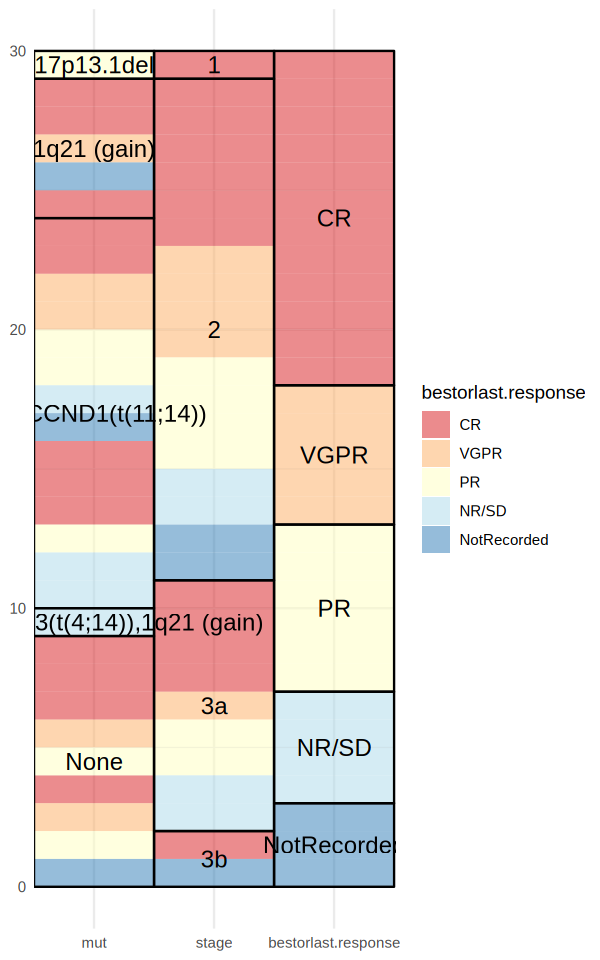

In [1]:
library(reshape2)
library(ggalluvial)
library(tidyverse)
library(RColorBrewer)

# Load data
db <- read.csv(file = 'sampleannotation-all.csv')
db[is.na(db)] <- 'NotRecorded'

# Ensure response is a factor in the desired order
db$bestorlast.response <- factor(db$bestorlast.response, levels = c("CR", "VGPR", "PR", "NR/SD", "NotRecorded"))

# Optional: also ensure 'type' and 'mut' are factors if you want control over their order too
db$type <- factor(db$type)
db$mut <- factor(db$mut)

# Plot, 1st draft
options(repr.plot.height=8,repr.plot.width=5)
ggplot(data = db, aes(axis1 = mut, axis2=stage, axis3= bestorlast.response)) +
  geom_alluvium(aes(fill = bestorlast.response), width = 1) +
  geom_stratum(width = 1, alpha = 0) +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 5, color = "black") +
  scale_x_discrete(limits = c( 'mut',"stage", 'bestorlast.response'), expand = c(.1, .1)) +
  theme_minimal() +
  scale_fill_brewer(palette = "RdYlBu")


Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


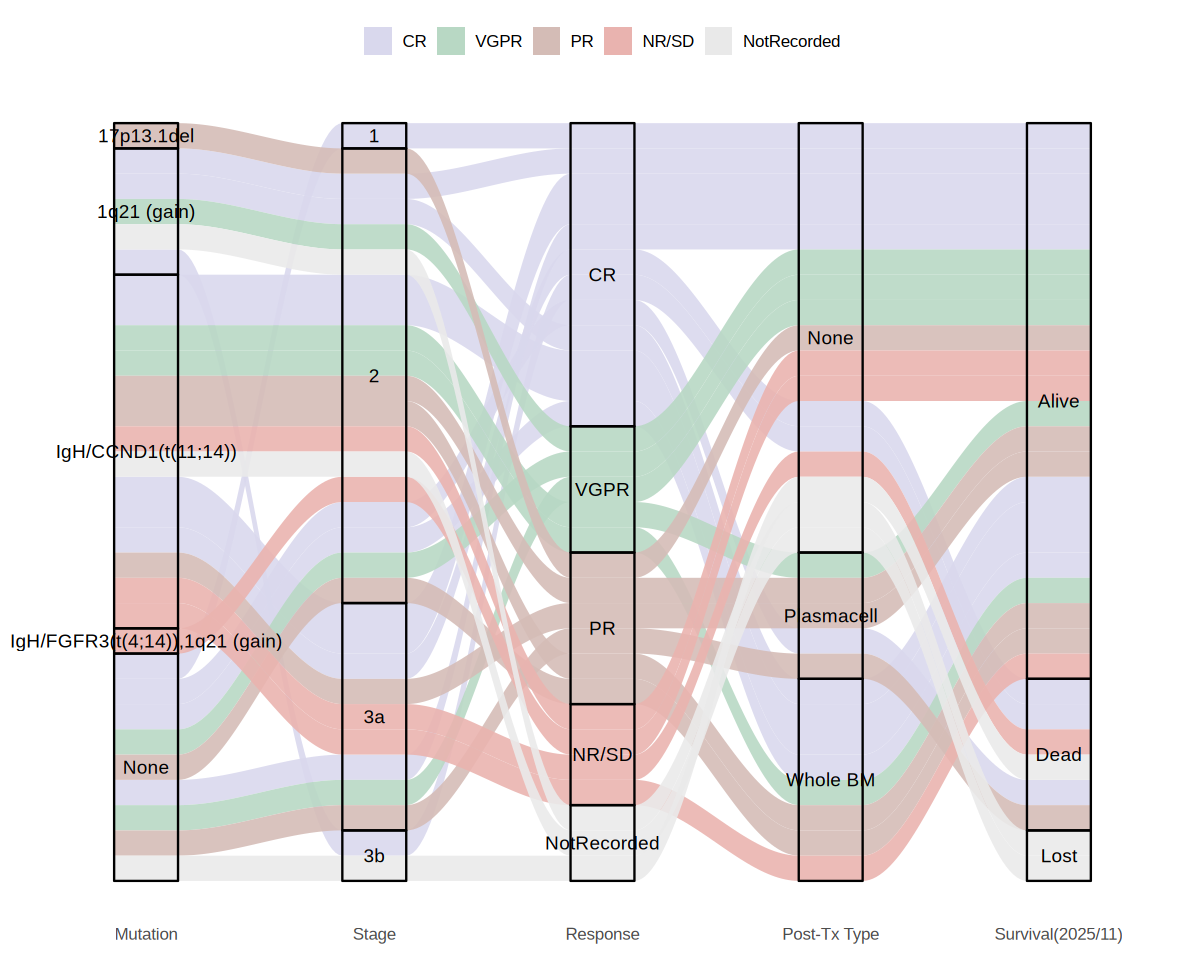

In [2]:
library(ggplot2)
library(ggalluvial)
library(dplyr)
library(forcats)   


# 1) Count and drop rows with NA in any axis var
db_counted <- db %>% count(mut, stage,post.treatment.type, bestorlast.response,  survival, name = "n")

# 2) Make factors (keeps ordering stable & palettes consistent)
db_counted <- db_counted %>%
  mutate(
    mut                 = factor(mut),
    stage               = factor(stage),
    bestorlast.response = factor(bestorlast.response),
    post.treatment.type = factor(post.treatment.type),
  )

# 3) Palette (expand if there are >5 response levels)
resp_lvls <- levels(db_counted$bestorlast.response)
biorender_pal <- c('#D9D8ED','#B8D8C4','#D4BCB6','#E9B3AF','#E9E9E9')
if (length(resp_lvls) > length(biorender_pal)) {
  # repeat colors if needed; replace with your own longer palette if you prefer
  biorender_pal <- rep(biorender_pal, length.out = length(resp_lvls))
}
pal <- setNames(biorender_pal[seq_along(resp_lvls)], resp_lvls)

axis_width <- 0.28  # a touch smaller is safer for dense plots

# 4) Plot

options(repr.plot.height = 8, repr.plot.width = 10)

p1 <-ggplot(
  db_counted,
  aes(
    axis1 = mut,
    axis2 = stage,
    axis3 = bestorlast.response,
    axis4 = post.treatment.type,
    axis5 = survival,
    y = n
  )
) +
  geom_alluvium(
    aes(fill = bestorlast.response),
    width = axis_width,
    curve_type = "cubic",
    knot.pos = 0.5,
    alpha = 0.9,
    color = NA
  ) +
  geom_stratum(
    width = axis_width,
    fill  = NA,
    color = TRUE
  ) +
  geom_text(
    stat = "stratum",
    aes(label = after_stat(stratum)),
    size = 4,
    color = "black"
  ) +
  # Include all four axes here, in the same order as axis1..axis4:
  scale_x_discrete(
    limits = c("mut", "stage", "bestorlast.response", "post.treatment.type","survival"),
    labels = c("Mutation", "Stage", "Response", "Post-Tx Type","Survival(2025/11)"),
    expand = c(0.08, 0.08)
  ) +
  scale_fill_manual(values = pal, drop = FALSE) +
  coord_cartesian(clip = "off") +
  theme_minimal(base_size = 12) +
  theme(
    panel.grid   = element_blank(),
    axis.title   = element_blank(),
    axis.text.y  = element_blank(),
    axis.ticks   = element_blank(),
    legend.position = "top",
    legend.title = element_blank(),
    plot.margin  = margin(10, 30, 10, 30)
  ) +
  guides(fill = guide_legend(override.aes = list(alpha = 1)))

p1

In [3]:
ggsave("sankey_sc.pdf", plot = p1, width = 8, height = 8, units = "in", dpi = 300)

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
